In [1]:
from random import seed

from pasta.base.scope import analyze
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.show()

NameError: name 'X_scaled' is not defined

In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 1,000 customers
n_customers = 1000

data = {
    'CustomerID': range(1, n_customers + 1),
    # Feature 1: Monthly Bill (USD)
    'MonthlyBill': np.concatenate([
        np.random.normal(40, 10, 400),  # Budget users
        np.random.normal(80, 15, 400),  # Mid-tier
        np.random.normal(150, 20, 200)  # Premium
    ]),
    # Feature 2: Data Usage (GB)
    'DataUsageGB': np.concatenate([
        np.random.normal(5, 2, 400),    # Low usage
        np.random.normal(25, 10, 400),  # Medium usage
        np.random.normal(100, 30, 200)  # Heavy streamers
    ]),
    # Feature 3: Days Since Last Contract Renewal
    'ContractDays': np.random.randint(30, 1000, n_customers),
    # Feature 4: Number of Support Tickets
    'SupportTickets': np.concatenate([
        np.random.poisson(1, 700),      # Satisfied customers
        np.random.poisson(6, 300)       # Frustrated customers
    ])
}

df = pd.DataFrame(data)
# Shuffle the data to mix the groups
df = df.sample(frac=1).reset_index(drop=True)

print(df.head())

   CustomerID  MonthlyBill  DataUsageGB  ContractDays  SupportTickets
0         280    36.146864     4.381767           862               0
1         895   177.643180    97.349111            79               8
2         831   123.110990   121.246433           368               8
3         108    41.745778     2.893169           890               2
4         490    93.224596    37.625841           170               0


In [2]:
df

,CustomerID,MonthlyBill,DataUsageGB,ContractDays,SupportTickets
0,280,36.146864,4.381767,862,0
1,895,177.643180,97.349111,79,8
2,831,123.110990,121.246433,368,8
3,108,41.745778,2.893169,890,2
4,490,93.224596,37.625841,170,0
...,...,...,...,...,...
995,604,100.334568,17.008080,311,0
996,573,84.903911,27.935579,143,0
997,165,49.633761,7.045141,42,0
998,825,141.089950,105.059640,954,12


In [18]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
df=df.drop("CustomerID", axis=1)
df_scaled=scaler.fit_transform(df)

In [20]:
df_scaled

array([[-0.9728546 , -0.73801384,  1.27849185, -0.88224356],
       [ 2.28709088,  1.69680937, -1.55768303,  1.97986044],
       [ 1.03071918,  2.32268239, -0.51087008,  1.97986044],
       ...,
       [-0.66212884, -0.66825983, -1.69170406, -0.88224356],
       [ 1.44493794,  1.89874882,  1.61173335,  3.41091244],
       [ 0.58806488,  0.29259795, -0.93828851, -0.88224356]],
      shape=(1000, 4))

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

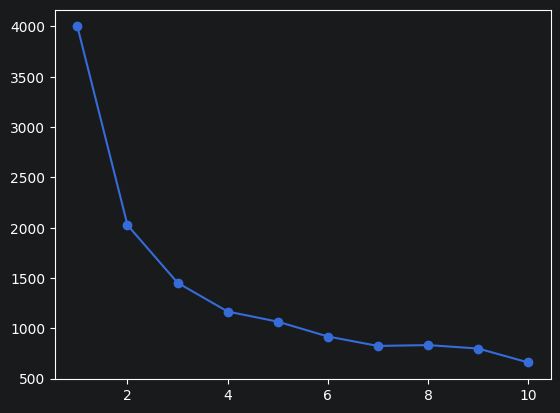

In [24]:
plt.plot(range(1,11),inertia ,marker='o' )
plt.show()

In [31]:
k_means=KMeans(n_clusters=4,random_state=42,n_init=42)
df_cluster = k_means.fit_predict(df_scaled)

df['Cluster'] = k_means.labels_

analyze = df.groupby('Cluster').mean()
analyze

,MonthlyBill,DataUsageGB,ContractDays,SupportTickets
Cluster,,,,
0,152.847693,101.978207,505.096939,6.030612
1,58.132570,15.177024,745.625323,1.136951
2,83.495587,24.833076,418.743590,6.961538
3,57.241967,14.049188,262.008850,0.887906


In [33]:
# Create a mapping based on your 'analysis' table observations
# Example mapping (check your specific means first!):
cluster_names = {
    0: "Budget User",
    1: "Premium Power User",
    2: "High-Risk / Frustrated",
    3: "Steady Regular"
}

df['Persona'] = df['Cluster'].map(cluster_names)
print(df[['MonthlyBill', 'SupportTickets', 'Persona']].head())

   MonthlyBill  SupportTickets             Persona
0    36.146864               0  Premium Power User
1   177.643180               8         Budget User
2   123.110990               8         Budget User
3    41.745778               2  Premium Power User
4    93.224596               0      Steady Regular


In [34]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.38


In [35]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_scaled, df['Cluster'])
print(f"Davies-Bouldin Index: {db_index:.2f}")

Davies-Bouldin Index: 0.98
